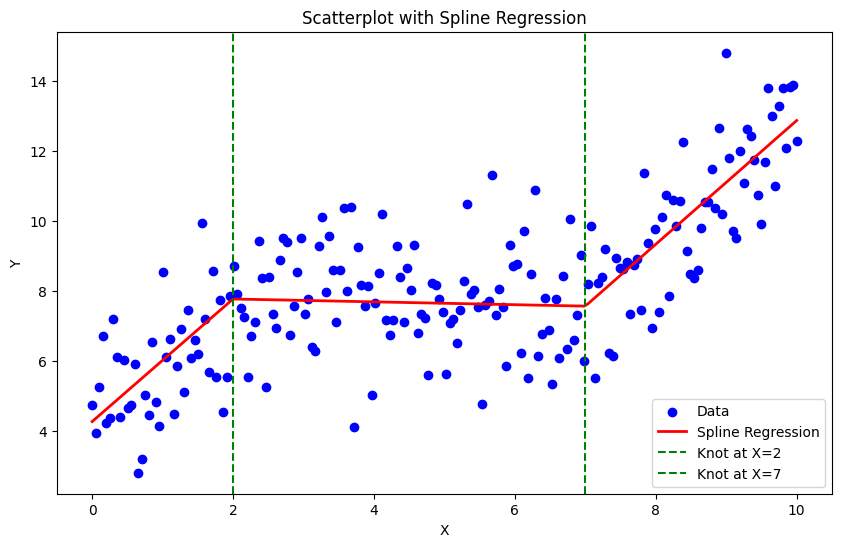

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import LSQUnivariateSpline
from sklearn.linear_model import LinearRegression
import patsy

# Simulate data
np.random.seed(42)
X = np.linspace(0, 10, 200)
Y = 4 + 3 * X - 0.7 * X**2 + 0.05 * X**3 + np.random.normal(scale=1.5, size=X.shape)  # Quadratic relationship with noise

# Define the knot for the spline
knot = [2,7]  # One knot at X=5

# Fit a linear regression spline
spline = LSQUnivariateSpline(X, Y, t=knot, k=1)  # k=1 for linear spline

# Predict Y values using the spline
Y_spline = spline(X)

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='blue', label='Data')
plt.plot(X, Y_spline, color='red', label='Spline Regression', linewidth=2)
plt.axvline(x=knot[0], color='green', linestyle='--', label='Knot at X=2')
plt.axvline(x=knot[1], color='green', linestyle='--', label='Knot at X=7')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatterplot with Spline Regression')
plt.legend()
plt.show()

In [2]:
spline_alt = patsy.bs(X, df=4, knots=[2,7], degree=2, include_intercept=False)

In [3]:
model = LinearRegression()
model.fit(spline_alt, Y)
Y_pred = model.predict(spline_alt)

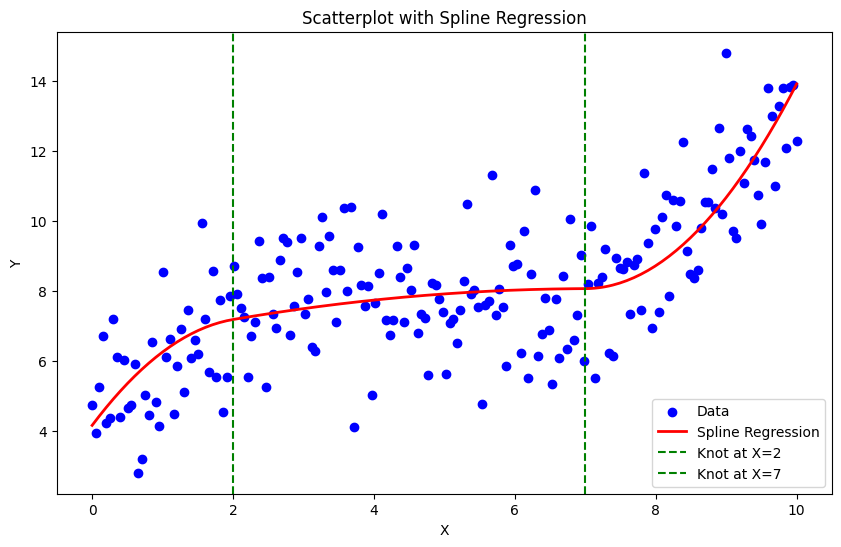

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='blue', label='Data')
plt.plot(X, Y_pred, color='red', label='Spline Regression', linewidth=2)
plt.axvline(x=knot[0], color='green', linestyle='--', label='Knot at X=2')
plt.axvline(x=knot[1], color='green', linestyle='--', label='Knot at X=7')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatterplot with Spline Regression')
plt.legend()
plt.show()

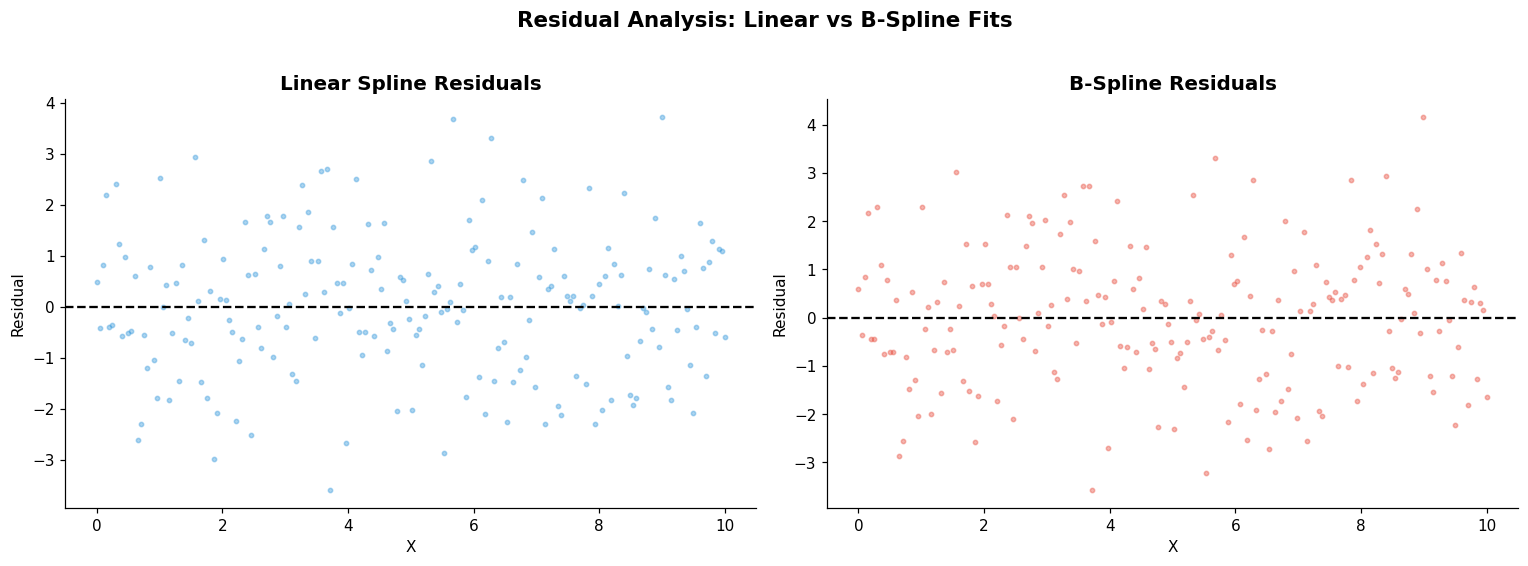

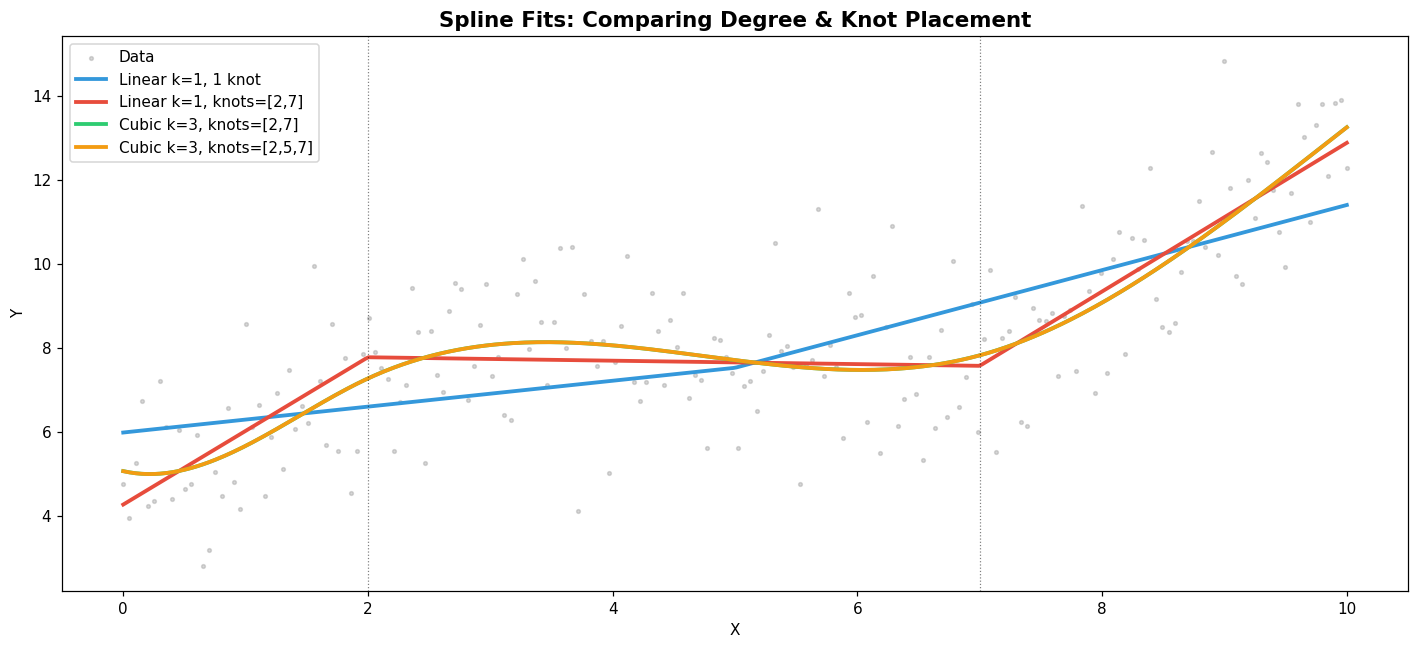

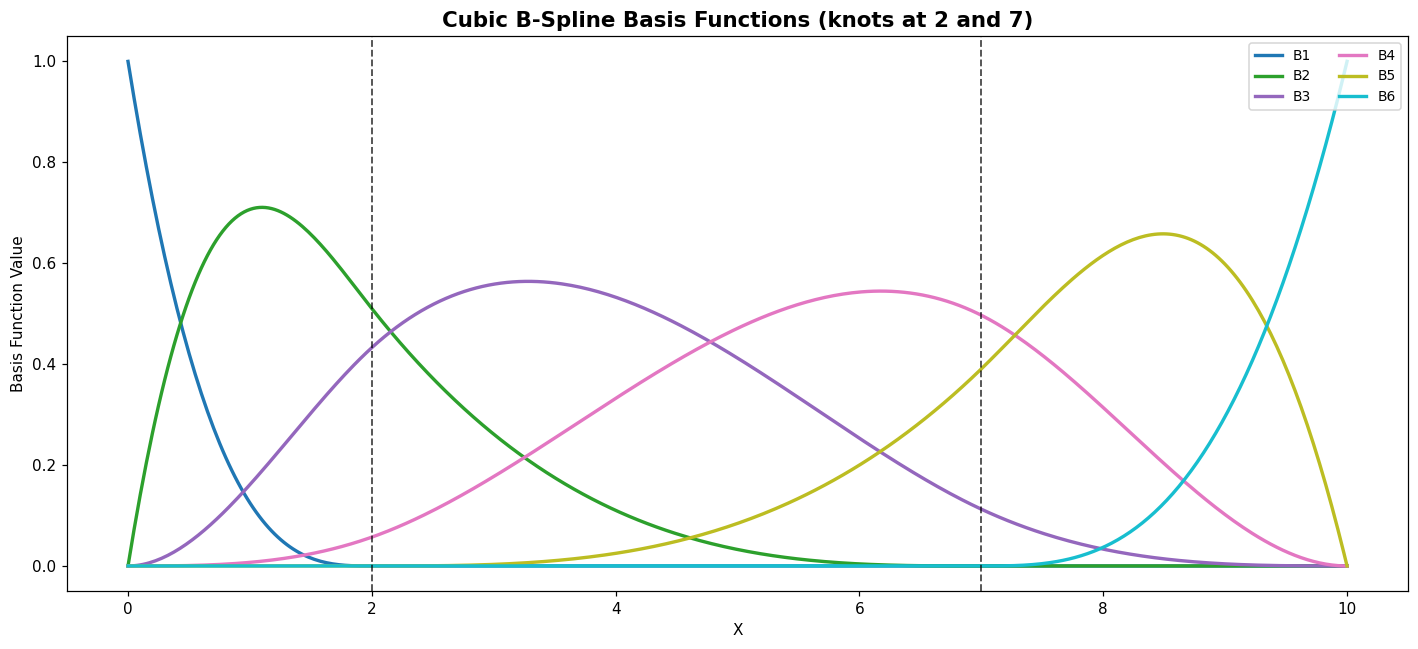

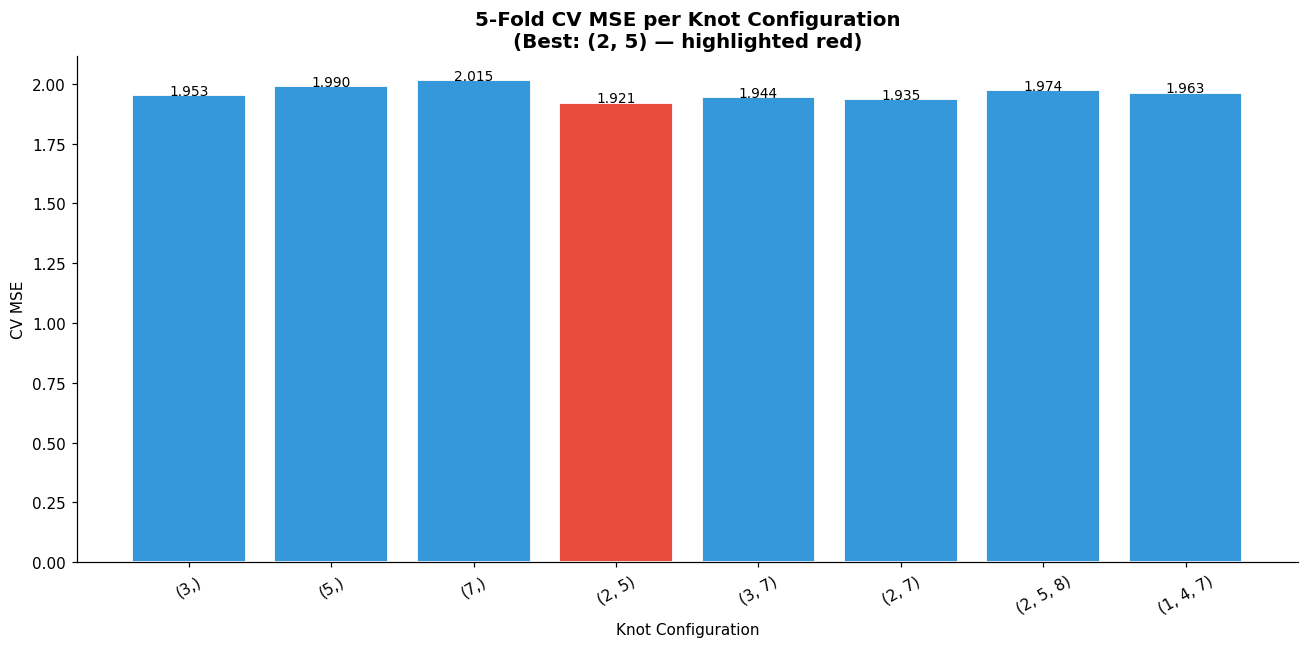

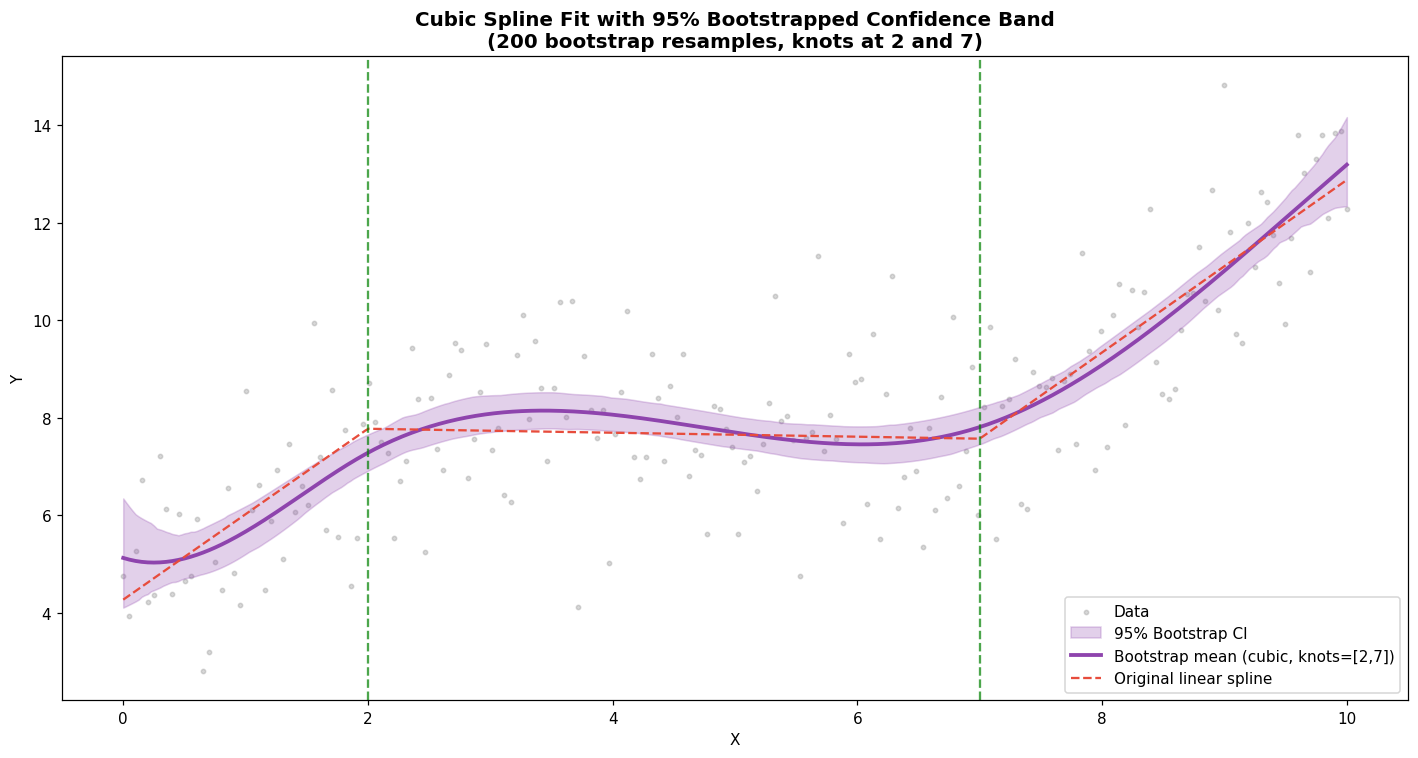

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110})

from scipy.interpolate import LSQUnivariateSpline
from sklearn.linear_model import LinearRegression
import patsy

# ── Easy: Residuals from Both Splines ────────────────────────────────────────
res_linear = Y - Y_spline
res_bspline = Y - Y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, res, title, color in [
    (axes[0], res_linear,  'Linear Spline Residuals',   '#3498db'),
    (axes[1], res_bspline, 'B-Spline Residuals',        '#e74c3c'),
]:
    ax.scatter(X, res, alpha=0.4, s=8, color=color)
    ax.axhline(0, color='black', lw=1.5, linestyle='--')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('X'); ax.set_ylabel('Residual')
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Residual Analysis: Linear vs B-Spline Fits', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ── Medium: Comparing Spline Degree & Knots ──────────────────────────────────
X_dense = np.linspace(X.min(), X.max(), 400)
configs = [
    ([5], 1, '#3498db', 'Linear k=1, 1 knot'),
    ([2, 7], 1, '#e74c3c', 'Linear k=1, knots=[2,7]'),
    ([2, 7], 3, '#2ecc71', 'Cubic k=3, knots=[2,7]'),
    ([2, 5, 7], 3, '#f39c12', 'Cubic k=3, knots=[2,5,7]'),
]
fig, ax = plt.subplots(figsize=(13, 6))
ax.scatter(X, Y, s=6, alpha=0.3, color='grey', label='Data')
for knots, degree, color, label in configs:
    try:
        sp = LSQUnivariateSpline(X, Y, t=knots, k=degree)
        ax.plot(X_dense, sp(X_dense), lw=2.5, color=color, label=label)
    except Exception:
        pass
for kn in [2, 7]:
    ax.axvline(kn, color='black', lw=0.8, linestyle=':', alpha=0.5)
ax.set_title('Spline Fits: Comparing Degree & Knot Placement', fontsize=14, fontweight='bold')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

# ── Medium: B-Spline Basis Functions ─────────────────────────────────────────
basis_df = patsy.bs(X_dense, df=6, knots=[2, 7], degree=3, include_intercept=True)
fig, ax = plt.subplots(figsize=(13, 6))
colors_basis = plt.cm.tab10(np.linspace(0, 1, basis_df.shape[1]))
for j in range(basis_df.shape[1]):
    ax.plot(X_dense, basis_df[:, j], lw=2.2, color=colors_basis[j], label=f'B{j+1}')
for kn in [2, 7]:
    ax.axvline(kn, color='black', lw=1.2, linestyle='--', alpha=0.7)
ax.set_title('Cubic B-Spline Basis Functions (knots at 2 and 7)', fontsize=14, fontweight='bold')
ax.set_xlabel('X'); ax.set_ylabel('Basis Function Value')
ax.legend(fontsize=9, ncol=2, loc='upper right')
plt.tight_layout(); plt.show()

# ── Hard: Cross-Validation over Knot Locations ───────────────────────────────
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error as _mse

knot_candidates = [(3,), (5,), (7,), (2, 5), (3, 7), (2, 7), (2, 5, 8), (1, 4, 7)]
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
cv_results = {}
for knots in knot_candidates:
    fold_mses = []
    for tr_idx, te_idx in kf.split(X):
        Xtr, Xte = X[tr_idx], X[te_idx]
        Ytr, Yte = Y[tr_idx], Y[te_idx]
        try:
            sp = LSQUnivariateSpline(Xtr, Ytr, t=list(knots), k=3)
            fold_mses.append(_mse(Yte, sp(Xte)))
        except Exception:
            fold_mses.append(np.nan)
    cv_results[str(knots)] = np.nanmean(fold_mses)

labels_cv = list(cv_results.keys())
vals_cv   = list(cv_results.values())
best_knot_lbl = labels_cv[np.argmin(vals_cv)]

fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = ['#e74c3c' if l == best_knot_lbl else '#3498db' for l in labels_cv]
bars = ax.bar(labels_cv, vals_cv, color=bar_colors, edgecolor='white', linewidth=1.2)
ax.set_title(f'5-Fold CV MSE per Knot Configuration\n(Best: {best_knot_lbl} — highlighted red)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Knot Configuration'); ax.set_ylabel('CV MSE')
ax.tick_params(axis='x', rotation=30)
ax.spines[['top','right']].set_visible(False)
for bar, v in zip(bars, vals_cv):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

# ── Hard: Uncertainty Bands via Bootstrapped Spline Fits ─────────────────────
np.random.seed(42)
n_boots = 200
boot_preds = []
for _ in range(n_boots):
    idx_b = np.random.choice(len(X), len(X), replace=True)
    Xb, Yb = np.sort(X[idx_b]), Y[idx_b][np.argsort(X[idx_b])]
    try:
        sp_b = LSQUnivariateSpline(Xb, Yb, t=[2, 7], k=3)
        boot_preds.append(sp_b(X_dense))
    except Exception:
        pass
boot_preds = np.array(boot_preds)
mean_pred = boot_preds.mean(axis=0)
lo_pred   = np.percentile(boot_preds, 2.5, axis=0)
hi_pred   = np.percentile(boot_preds, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(13, 7))
ax.scatter(X, Y, s=8, alpha=0.3, color='grey', label='Data')
ax.fill_between(X_dense, lo_pred, hi_pred, alpha=0.25, color='#8e44ad', label='95% Bootstrap CI')
ax.plot(X_dense, mean_pred, lw=2.5, color='#8e44ad', label='Bootstrap mean (cubic, knots=[2,7])')
ax.plot(X_dense, spline(X_dense), '--', lw=1.5, color='#e74c3c', label='Original linear spline')
for kn in [2, 7]:
    ax.axvline(kn, color='green', lw=1.5, linestyle='--', alpha=0.7)
ax.set_title('Cubic Spline Fit with 95% Bootstrapped Confidence Band\n(200 bootstrap resamples, knots at 2 and 7)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()